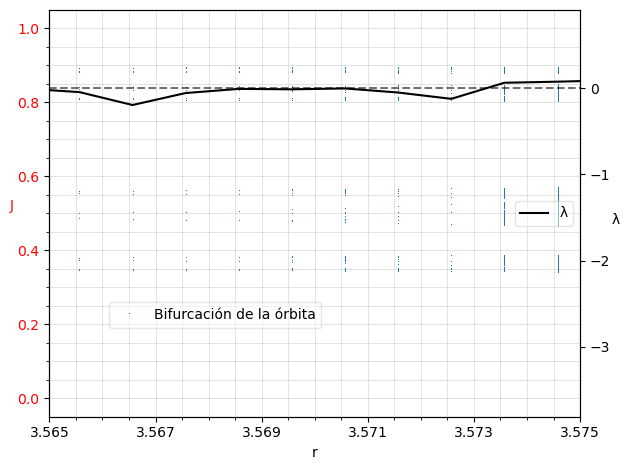

In [ ]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.interpolate import PchipInterpolator

def J_univariante(X):
    def distancia(p1, p2):
        return np.linalg.norm(np.array(p2) - np.array(p1))
    X = np.array(X)
    x1 = X[1:]
    y1 = X[:-1]
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))


    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([distancia(p1, c) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J

def lyapunov_exponent_from_orbit(orbit, r):
    lyapunov_sum = 0

    for x in orbit:
        # Derivada de la función logística
        derivative = abs(r * (1 - 2 * x))
        if derivative == 0:
            lyapunov_sum += 0
        else:
            lyapunov_sum += np.log(derivative)

    # Calcular el exponente de Lyapunov
    lyapunov_exponent = lyapunov_sum / len(orbit)
    return lyapunov_exponent

"""interpolacion despues de dinamica simbolica"""


def logistic_map(r, x):
    return r * x * (1 - x)
# 3000 y 2000, 1000000 y 35000, 3000 y 500
def plot_orbit_diagram(graficar=True, r_min = 3.0, r_max = 4.0, num_points_per_r=1000,
 num_iterations_discard=3000, num_iterations_display=1000):

    r_values = []
    orbit_values = []
    
    for r in np.linspace(r_min, r_max, num_points_per_r):
        if r == 3.0:
            continue
        x = 0.6
        for _ in range(num_iterations_discard): # Converger
            # x = np.clip(x, 0.0, 1.0)
            x = logistic_map(r, x) 
        for _ in range(num_iterations_display):
            # x = np.clip(x, 0.0, 1.0)
            x = logistic_map(r, x) 
            r_values.append(r)
            orbit_values.append(x)
        
    #A partir de aqui, orbita continua de logistica completada

    a = 0
    J_values=[]
    J_index=[]
    lyapunov_values = []
    b=0
    
    for i in range(0, len(r_values) - 1):
        if r_values[i] != r_values[i+1]:
            r_single_orbit = orbit_values[a:i+1]
            a = i+1


            lyapunov = lyapunov_exponent_from_orbit(r_single_orbit, r_values[i])
            lyapunov_values.append(lyapunov)
            # J_values.append(J)
            J_index.append(r_values[i])
            b += 1

    #ultimo valor de r
    lyapunov = lyapunov_exponent_from_orbit(orbit_values[a:], r_values[len(r_values) - 1])  
    lyapunov_values.append(lyapunov)
    r_single_orbit = orbit_values[a:]
    
    # J_values.append(J)
    J_index.append(r_values[len(r_values) - 1])
    """A partir de aqui, lyapunob y J fueron calculados"""
    
    
    if graficar == True:
        fig, ax1 = plt.subplots()#figsize=(10,6)
        # ax1.plot(J_index, J_values, color='red', label='J' , alpha = 1)
        ax1.plot(r_values, orbit_values, ',', label='Bifurcación de la órbita', alpha=1)
        ax1.set_xlabel('r') #.9873
        Namano = ((num_iterations_display-1) + num_iterations_display)//2
        if Namano > 13920:
            umbral = 0.99
        else:
            umbral = np.load('J_minus_continuo.npy')[1,np.where(np.load('J_minus_continuo.npy')[0,:] == Namano)]
        # ax1.axhline(y = umbral, color='green', linestyle='--', alpha =0.55,label='Umbral') # y = 0.9873 y = 0.94 y = 0.88
        ax1.set_ylabel('J', color='r', rotation = 360)
        ax1.tick_params(axis='y', labelcolor='r')
        ax1.legend(loc='center left', bbox_to_anchor=(0.1, 0.25), framealpha=0.5)
        ax1.set_xlim(3.565, 3.575)

        
        major_ticks_x = np.linspace(3.565, 3.575, 6)  # 0.0, 0.2, ..., 1.0
        minor_ticks_x = np.linspace(3.565, 3.575, 21)  # Ticks secundarios

        major_ticks_y = np.linspace(0, 1, 6)  # -1, -0.5, 0, 0.5, 1.0
        minor_ticks_y = np.linspace(0, 1, 21)  # Ticks secundarios

        # Configurar los ticks del eje X
        plt.xticks(major_ticks_x)  # Solo etiquetar los ticks principales
        plt.gca().set_xticks(minor_ticks_x, minor=True)  # Agregar ticks menores sin etiquetas

        # Configurar los ticks del eje Y
        plt.yticks(major_ticks_y)  # Solo etiquetar los ticks principales
        plt.gca().set_yticks(minor_ticks_y, minor=True)  # Agregar ticks menores sin etiquetas

        # Activar la cuadrícula
        plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)  # Para ticks principales
        plt.grid(which='minor', linestyle='-', linewidth=0.5, alpha=0.5)         

        ax2 = ax1.twinx()
        ax2.axhline(y=0, color='black', linestyle='--', alpha =0.55)
        ax2.plot(J_index, lyapunov_values, 'black', label = 'λ')
        ax2.set_ylabel('λ', color='black', rotation = 360)
        ax2.tick_params(axis='y', labelcolor='black')
        ax2.legend(loc='center right',framealpha=0.5)
            # ax2.set_xlim(3.571906, 4.0)
        
        fig.tight_layout()  

        plt.show()
        # J_values = np.array(J_values)
        lyapunov_values = np.array(lyapunov_values)

    return lyapunov_values, J_index


lyapunov_values, J_index = plot_orbit_diagram()

In [1]:
import numpy as np

def logistic_map(r, x):
    return r * x * (1 - x)

In [ ]:
import numpy as np

def logistic_map(r, x):
    return r * x * (1 - x)

x = 0.6
num_iterations_discard = 1000
num_iterations_display = 100000000
orbit_values = []
r = 3.5699431086217244
for _ in range(num_iterations_discard): # Converger
    x = logistic_map(r, x) 
for n in range(num_iterations_display):
    x = logistic_map(r, x) 
    if n == num_iterations_display//2:
        print('la mitad')
    orbit_values.append(x)

len(orbit_values)
# exp = lyapunov_exponent_from_orbit(orbit_values,r)
# J = J_univariante(orbit_values)
# J

la mitad


100000000

In [ ]:
import numpy

numpy.arange(10)

In [7]:
np.save('logistic_serie_r_infny.npy',orbit_values)

In [6]:
import pandas as pd

df = pd.DataFrame(orbit_values, columns=['Valores'])
df.to_csv('logistic_serie_r_infny.csv', index=False)

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


KeyboardInterrupt: 

In [88]:
def buscar_r_critico(r_min, r_max, pasos, precision=1e-8):
    mejor_r = None
    mejor_exp = float('inf')
    resultados = []

    for r in np.linspace(r_min, r_max, pasos):
        x = 0.6
        for _ in range(1000):  # Burn-in
            x = logistic_map(r, x)
        orbit = []
        for _ in range(10000):
            x = logistic_map(r, x)
            orbit.append(x)

        exp = lyapunov_exponent_from_orbit(orbit, r)
        resultados.append((r, exp))
        if abs(exp) < abs(mejor_exp):
            mejor_exp = exp
            mejor_r = r

        if abs(exp) < precision:
            break

    return mejor_r, mejor_exp, resultados

# Búsqueda en torno a r_infinito
r_critico, exp_min, datos = buscar_r_critico(3.5699, 3.5700, pasos=5000)

print(f"Mejor r encontrado: {r_critico}")
print(f"Exponente de Lyapunov: {exp_min}")


Mejor r encontrado: 3.5699431086217244
Exponente de Lyapunov: -7.870048455734205e-07
